In [1]:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

def euclidian_distance(o1, o2):
    row1, col1 = o1
    row2, col2 = o2
    return ((row1 - row2)**2 + (col1 - col2)**2)**0.5


def kNN(O_star, o_, k, d):
    print(f"Unseen observation: {o_}")
    print(f"k = {k}")
    print("\n--- Step 1: Calculate distances ---")

    distances = []

    for (oi, ci) in O_star:
        distance = d(o_, oi)
        distances.append((distance, oi, ci))
        print(f"Observation {oi}, class = {ci},  distance = {distance}")

    print("\n--- Step 2: Sort by distance ---")
    distances.sort()
    for distance, oi, ci in distances: print(f"Observation {oi}, class = {ci},  distance = {distance}")

    print(f"\n--- Step 3: Select {k} nearest neighbors ---")
    neighbors = distances[0:k]
    for i, (distance, oi, ci) in enumerate(neighbors, start=1): print(f"Neighbor {i}: position = {oi}, class = {ci}, distance = {distance}")

    print("\n--- Step 4: Count classes ---")

    counts = {}

    for distance, oi, ci in neighbors:
        if ci not in counts: counts[ci] = 0
        counts[ci] += 1

    for ci, count in counts.items(): print(f"Class {ci}: {count} neighbor(s)")

    print("\n--- Step 5: Find majority class ---")

    best_class = None
    best_count = -1
    for ci in counts:
        if counts[ci] > best_count:
            best_class = ci
            best_count = counts[ci]

    print(f"Predicted class: {best_class}")

    return best_class


In [5]:
digit_8 = [
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [1, 1,'', 0, 0, 0, 0, 1, 1, 0], # (1, 2) -> missing color
    [1, 1, 0, 0, 0, 0, 0, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
    [1, 1, 0, 0, 0, 0, 0, 1, 1, 0],
    [1, 1, 0, 0, 0, 0, 0, 1, 1, 0],
    [1, 1, 0, 0, 0, 0, 0, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]

o_ = (1, 2) #The missing pixel

digit_8_half_left = [
    [0, 1, 1, 1, 1, '', '', '', '', ''],
    [1, 1, 0, 0, 0, '', '', '', '', ''],
    [1, 1, 0, 0, 0, '', '', '', '', ''],
    [0, 1, 1, 1, 1, '', '', '', '', ''],
    [0, 0, 1, 1, 1, '', '', '', '', ''],
    [1, 1, 0, 0, 0, '', '', '', '', ''],
    [1, 1, 0, 0, 0, '', '', '', '', ''],
    [1, 1, 0, 0, 0, '', '', '', '', ''],
    [0, 1, 1, 1, 1, '', '', '', '', ''],
    [0, 0, 0, 0, 0, '', '', '', '', '']
]

o_list = [(i, j) for i in range(10) for j in range(5, 10)] #[0:9, 5:] missing pixels in the right side
o_list = [
    (0,5), (0,6), (0,7), (0,8), (0,9),
    (1,5), (1,6), (1,7), (1,8), (1,9),
    (2,5), (2,6), (2,7), (2,8), (2,9),
    (3,5), (3,6), (3,7), (3,8), (3,9),
    (4,5), (4,6), (4,7), (4,8), (4,9),
    (5,5), (5,6), (5,7), (5,8), (5,9),
    (6,5), (6,6), (6,7), (6,8), (6,9),
    (7,5), (7,6), (7,7), (7,8), (7,9),
    (8,5), (8,6), (8,7), (8,8), (8,9),
    (9,5), (9,6), (9,7), (9,8), (9,9)
]



In [7]:
# Create O* from all known pixels

O_star = []
for row in digit_8: print(row)
for row in range(len(digit_8)):
    for col in range(len(digit_8[row])):
        if digit_8[row][col] != '':
            observation = (row, col)
            true_class = digit_8[row][col]
            O_star.append((observation, true_class))

k=3
prediction = kNN(O_star, o_, k=k, d=euclidian_distance)
digit_8[o_[0]][o_[1]] = prediction
for row in digit_8: print(" ".join("█" if x == 1 else "·" for x in row))

# for row in digit_8_half_left: print(row)
# O_star = []
# for row in range(len(digit_8_half_left)):
#     for col in range(len(digit_8_half_left[row])):
#         if digit_8_half_left[row][col] != '':
#             observation = (row, col)
#             true_class = digit_8_half_left[row][col]
#             O_star.append((observation, true_class))

# k=10
# for o_ in o_list:
#     prediction = kNN(O_star, o_, k=k, d=euclidian_distance)
#     digit_8_half_left[o_[0]][o_[1]] = prediction
# for row in digit_8_half_left: print(" ".join("█" if x == 1 else "·" for x in row))

[0, 1, 1, 1, 1, 1, 1, 1, 0, 0]
[1, 1, 1, 0, 0, 0, 0, 1, 1, 0]
[1, 1, 0, 0, 0, 0, 0, 1, 1, 0]
[0, 1, 1, 1, 1, 1, 1, 1, 0, 0]
[0, 0, 1, 1, 1, 1, 1, 1, 0, 0]
[1, 1, 0, 0, 0, 0, 0, 1, 1, 0]
[1, 1, 0, 0, 0, 0, 0, 1, 1, 0]
[1, 1, 0, 0, 0, 0, 0, 1, 1, 0]
[0, 1, 1, 1, 1, 1, 1, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Unseen observation: (9, 9)
k = 3

--- Step 1: Calculate distances ---
Observation (0, 0), class = 0,  distance = 12.727922061357855
Observation (0, 1), class = 1,  distance = 12.041594578792296
Observation (0, 2), class = 1,  distance = 11.40175425099138
Observation (0, 3), class = 1,  distance = 10.816653826391969
Observation (0, 4), class = 1,  distance = 10.295630140987
Observation (0, 5), class = 1,  distance = 9.848857801796104
Observation (0, 6), class = 1,  distance = 9.486832980505138
Observation (0, 7), class = 1,  distance = 9.219544457292887
Observation (0, 8), class = 0,  distance = 9.055385138137417
Observation (0, 9), class = 0,  distance = 9.0
Observation (1, 0), cla

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2) #p=2 -> Euclidean 2d points distance

X, y = zip(*O_star)
knn.fit(X, y) # Train k-NN >> Dummy

unseen_pixel = [o_] #the unseen pixel

prediction = knn.predict(unseen_pixel) #inference
print("Predicted pixel value:", prediction[0])

Predicted pixel value: 0


In [ ]:
#Report the nearest neighbors (just for log purposes)
distances, indices = knn.kneighbors(unseen_pixel)
print("\n--- Nearest neighbors ---")
for i in range(k):
    index = indices[0][i]
    distance = distances[0][i]
    position = X[index]
    pixel_value = y[index]
    print(f"Neighbor {i + 1}: position = {position}, value = {pixel_value}, distance = {distance}")

#Report the votes per class, normalized in [0, 1] as probs (just for log purposes)
print("\n--- Class probabilities ---")
probabilities = knn.predict_proba(unseen_pixel) #Show the class probabilities / votes
for class_value, probability in zip(knn.classes_, probabilities[0]): print(f"Class {class_value}:  {probability:.2f}")


--- Nearest neighbors ---
Neighbor 1: position = (2, 2), value = 0, distance = 1.0
Neighbor 2: position = (1, 1), value = 1, distance = 1.0
Neighbor 3: position = (1, 3), value = 0, distance = 1.0

--- Class probabilities ---
Class 0:  0.67
Class 1:  0.33


**kNN Sensitivity to k ...**

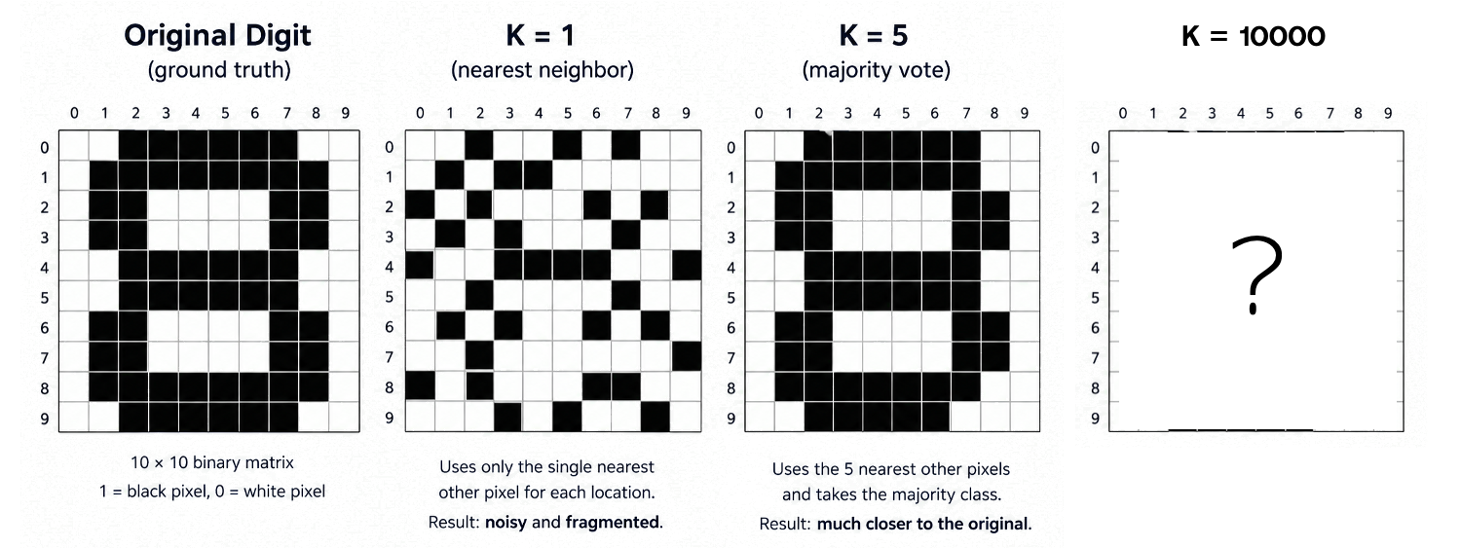

**kNN as Generative AI?**

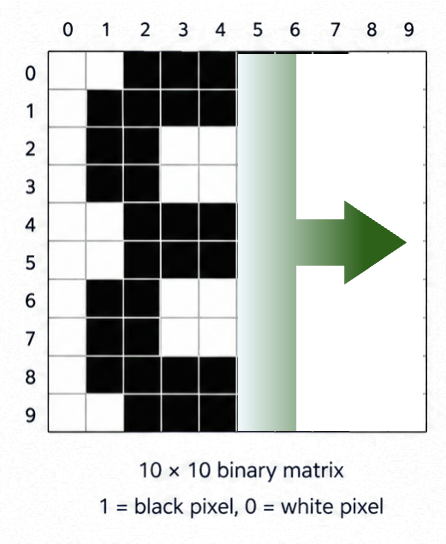